# Read data (all 12 csv files)

nyc_taxi csv files are expected to be in the `data/` directory.

In [5]:
import dataset                          # Data loader
import pandas as pd                     # For the data manipulation
import numpy as np                      # For the numerical operations
import matplotlib.pyplot as plt         # Plots
import seaborn as sns                   # This is for the plots to look better

from xgboost import XGBRegressor        # Make sure to install pip install xgboost
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Dataset metadata

In [6]:
# Pulling total data is 4M - things get buggy;
# Using month 1 & 2 for now
df = dataset.raw(month_start=1, month_end=2)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
df.head(3)

Shape: (5972150, 20)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'month']

First 3 rows:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,month
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0,1
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0,1
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0,1


C:\Users\Bhaskar\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


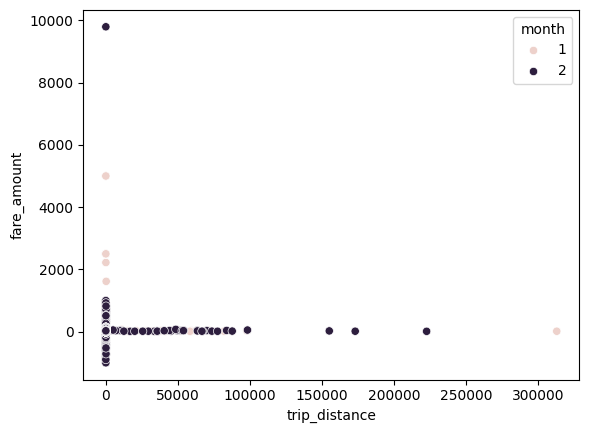

In [4]:
sns.scatterplot(data=df, x='trip_distance', y='fare_amount', hue='month')
plt.show()

## The data contains ALL NYC boroughs but we only care about Manhattan thus
###  We use the taxi zone lookup to filter down to Manhattan only


In [ ]:
zones = pd.read_csv("../../data/taxi_zone_lookup.csv")
